# Do Today’s Strongest Currencies Stay Strong Tomorrow?

### A five-year case study of momentum versus mean reversion across the eight major currencies

**Decision question:** Does ranking the major currencies by today’s cross-market strength create a useful one-day forecast?

**Scope:** 2021-08-03 to 2026-07-31 · 1,299 synchronized daily return observations · 28 currency pairs · 8 currencies

---

## TL;DR

The four strongest currencies on day $t$ earned an average **-0.0086%** strength score on day $t+1$. A moving-block bootstrap 95% confidence interval was **[-0.0179%, +0.0003%]**, which includes zero. Continuation occurred on **46.6%** of days.

The unconditional mean is close to zero, but the dependence tests reveal a small reversal pattern. Continuation occurred on **46.6%** of days (two-sided sign-test $p=0.016$), and the Newey–West $p_0 \rightarrow p_1$ slope was **-0.141** ($p=0.001$). The Pearson correlation was **-0.118** ($p=0.000$).

**Finding:** the data reject a one-day momentum story and instead show **weak statistical mean reversion**: more extreme day-0 leaders tended to give back a small amount of strength on day 1. The average effect is only about 0.86 basis points in this non-tradable index, and it fades at longer daily horizons.

> **Stakeholder implication:** Do not promote yesterday’s top-four ranking as a momentum signal. Treat the reversal pattern as a research lead—not a trading strategy—until it survives a pre-registered out-of-sample test and transaction-cost modeling.

## Context & Methods

### Purpose

Currency pairs make relative moves easy to observe but individual currencies harder to compare. This project creates a single daily strength score for each of the eight major currencies, ranks those scores, and asks whether the leaders retain strength on the next trading day.

### Hypothesis

- **Null ($H_0$):** the top-four group’s expected next-day strength is zero, and today’s group strength ($p_0$) does not predict next-day strength ($p_1$).
- **Momentum alternative:** $E[p_1] > 0$ and/or the $p_0 \rightarrow p_1$ slope is positive.
- **Mean-reversion alternative:** $E[p_1] < 0$ and/or the slope is negative.

### Analytical flow

`28 FX closing-price series` → `daily log returns` → `8 currency-strength scores` → `top four on day t` → `same four currencies on day t+1`

### Key assumptions

- Yahoo Finance daily closes are treated as synchronized observations; dates missing from any pair are excluded.
- Log returns are used because reversing a quote changes only the sign, which preserves the cross-currency accounting identity.
- Each currency score is the equal-weighted average contribution from its seven pairs.
- The strength score is an analytical index, not a directly investable portfolio return.
- The primary test is one day ahead. Confidence intervals use a 10-day moving-block bootstrap; regression inference uses Newey–West standard errors with five lags.

In [1]:
# Setup: imports, parameters, and a restrained visual system
from itertools import combinations
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

CURRENCIES = ["EUR", "USD", "JPY", "GBP", "CHF", "AUD", "CAD", "NZD"]
START_DATE = "2021-08-01"
END_DATE = "2026-08-01"
CACHE_PATH = Path("data/fx_prices_2021-08-01_2026-08-01.csv")
RANDOM_SEED = 42

BLUE = "#2F5D8C"
BLUE_LIGHT = "#B8CCE0"
GOLD = "#C6922B"
INK = "#25313C"
GREY = "#7A8793"
GRID = "#DCE2E7"
BG = "#FAFBFC"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": GREY,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "font.family": "DejaVu Sans",
})

## Data

The universe contains all $\binom{8}{2}=28$ unique combinations of EUR, USD, JPY, GBP, CHF, AUD, CAD, and NZD. The repository includes a frozen CSV snapshot for reproducibility. If the file is missing—for example in a standalone Colab upload—the next cell downloads the same date range and recreates it.

**Source:** Yahoo Finance via [`yfinance`](https://ranaroussi.github.io/yfinance/). Data are intended for research and demonstration, not production trading.

In [2]:
def download_fx_prices(currencies, start_date, end_date):
    series_by_pair = {}
    ticker_map = {}

    for first, second in combinations(currencies, 2):
        for base, quote in ((first, second), (second, first)):
            pair = base + quote
            ticker = f"{pair}=X"
            raw = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                interval="1d",
                auto_adjust=False,
                progress=False,
                threads=False,
            )
            if raw.empty or "Close" not in raw:
                continue
            close = raw["Close"]
            if isinstance(close, pd.DataFrame):
                close = close.iloc[:, 0]
            close = pd.to_numeric(close, errors="coerce").dropna()
            if close.empty:
                continue
            close.name = pair
            series_by_pair[pair] = close
            ticker_map[pair] = ticker
            break
        else:
            raise RuntimeError(f"No series found for {first}/{second}")

    prices = pd.concat(series_by_pair.values(), axis=1).sort_index()
    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    return prices, ticker_map


if CACHE_PATH.exists():
    prices = pd.read_csv(CACHE_PATH, index_col="Date", parse_dates=True)
    ticker_map = {column: f"{column}=X" for column in prices.columns}
    data_source = f"Cached snapshot: {CACHE_PATH.as_posix()}"
else:
    prices, ticker_map = download_fx_prices(CURRENCIES, START_DATE, END_DATE)
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    prices.to_csv(CACHE_PATH, index_label="Date")
    data_source = "Fresh Yahoo Finance download (then cached locally)"

print(data_source)
print(f"Raw shape: {prices.shape[0]:,} dates × {prices.shape[1]} pairs")
display(prices.head(3))

Cached snapshot: data/fx_prices_2021-08-01_2026-08-01.csv
Raw shape: 1,300 dates × 28 pairs


,EURUSD,EURJPY,EURGBP,EURCHF,EURAUD,EURCAD,EURNZD,USDJPY,USDGBP,USDCHF,...,GBPCHF,GBPAUD,GBPCAD,GBPNZD,CHFAUD,CHFCAD,CHFNZD,AUDCAD,AUDNZD,CADNZD
Date,,,,,,,,,,,,,,,,,,,,,
2021-08-02,1.1867,130.1810,0.8539,1.0749,1.6161,1.4789,1.7012,109.7060,0.7196,0.9059,...,1.2587,1.8925,1.7322,1.9921,1.5033,1.3760,1.5825,0.9152,1.0526,1.1498
2021-08-03,1.1875,129.7440,0.8547,1.0746,1.6132,1.4843,1.6993,109.2690,0.7198,0.9053,...,1.2574,1.8871,1.7364,1.9880,1.5005,1.3807,1.5808,0.9201,1.0535,1.1447
2021-08-04,1.1869,129.3610,0.8528,1.0728,1.6046,1.4875,1.6847,108.9910,0.7185,0.9038,...,1.2578,1.8814,1.7441,1.9751,1.4956,1.3865,1.5702,0.9270,1.0498,1.1323


In [3]:
# Data-quality checks at the analytical grain
expected_pairs = len(list(combinations(CURRENCIES, 2)))
audit = pd.Series({
    "expected_unique_pairs": expected_pairs,
    "downloaded_pair_series": prices.shape[1],
    "raw_trading_dates": prices.shape[0],
    "dates_complete_across_all_pairs": int(prices.notna().all(axis=1).sum()),
    "duplicate_dates": int(prices.index.duplicated().sum()),
    "nonpositive_prices": int((prices <= 0).sum().sum()),
    "max_pair_missing_share": prices.isna().mean().max(),
}).to_frame("value")

assert prices.shape[1] == expected_pairs, "The 28-pair universe is incomplete."
assert not prices.columns.duplicated().any(), "Duplicate pair columns found."
assert prices.index.is_monotonic_increasing, "Dates must be sorted."
assert audit.loc["duplicate_dates", "value"] == 0, "Duplicate dates found."
assert audit.loc["nonpositive_prices", "value"] == 0, "Prices must be positive."
display(audit)

,value
expected_unique_pairs,28.0000
downloaded_pair_series,28.0000
raw_trading_dates,"1,300.0000"
dates_complete_across_all_pairs,"1,300.0000"
duplicate_dates,0.0000
nonpositive_prices,0.0000
max_pair_missing_share,0.0000


In [4]:
# Convert pair returns into equal-weighted individual-currency strength
pair_returns = np.log(prices / prices.shift(1)).mul(100).dropna(how="any")

currency_strength = pd.DataFrame(
    0.0, index=pair_returns.index, columns=CURRENCIES
)
pair_counts = pd.Series(0, index=CURRENCIES, dtype=int)

for pair in pair_returns.columns:
    base, quote = pair[:3], pair[3:]
    currency_strength[base] += pair_returns[pair] / 7
    currency_strength[quote] -= pair_returns[pair] / 7
    pair_counts[[base, quote]] += 1

assert pair_counts.eq(7).all(), "Every currency must contribute through seven pairs."
assert np.allclose(currency_strength.sum(axis=1), 0, atol=1e-10)

print(
    f"Analytical sample: {len(currency_strength):,} synchronized daily returns "
    f"from {currency_strength.index.min().date()} to {currency_strength.index.max().date()}"
)
display(currency_strength.head(3))

Analytical sample: 1,299 synchronized daily returns from 2021-08-03 to 2026-07-31


,EUR,USD,JPY,GBP,CHF,AUD,CAD,NZD
Date,,,,,,,,
2021-08-03,-0.0187,-0.0940,0.3601,-0.1325,-0.0114,0.1984,-0.4101,0.1083
2021-08-04,-0.2727,-0.2315,0.0680,-0.0188,-0.0541,0.3209,-0.5274,0.7156
2021-08-05,-0.0889,0.2213,-0.3379,-0.0007,-0.1272,0.0106,0.1230,0.1997


In [5]:
# Coherence check: cross rates should approximately close around every currency triangle
available_pairs = set(pair_returns.columns)

def directed_return(base, quote):
    direct = base + quote
    if direct in available_pairs:
        return pair_returns[direct]
    return -pair_returns[quote + base]


triangle_residuals = pd.concat([
    directed_return(first, second)
    + directed_return(second, third)
    + directed_return(third, first)
    for first, second, third in combinations(CURRENCIES, 3)
], axis=1)

triangle_audit = pd.Series({
    "currency_triangles": triangle_residuals.shape[1],
    "median_absolute_cycle_residual_pct": triangle_residuals.abs().stack().median(),
    "p95_absolute_cycle_residual_pct": triangle_residuals.abs().stack().quantile(0.95),
}).to_frame("value")
display(triangle_audit)

,value
currency_triangles,56.0000
median_absolute_cycle_residual_pct,0.0115
p95_absolute_cycle_residual_pct,0.1174


### Data-source coherence caveat

Perfectly synchronized FX quotes would sum to zero around every three-currency cycle. The median absolute cycle discrepancy is **0.0115%**, while the 95th percentile is **0.1174%**. The typical mismatch is small, but the upper tail confirms that these public closing series are not an institutional synchronized panel. A seven-USD-leg sensitivity test later checks whether this redundancy drives the main result.

### Why the two four-currency groups mirror each other

Every pair contributes the same return once positively (to its base currency) and once negatively (to its quote currency). Therefore, on every date:

$$\sum_{c=1}^{8} \text{strength}_{c,t}=0$$

Splitting all eight currencies into two equal groups implies:

$$\operatorname{mean}(\text{top 4})=-\operatorname{mean}(\text{bottom 4})$$

This is an accounting identity created by the feature engineering—not a market finding. The analysis therefore keeps the top-four signal as the primary outcome and uses the bottom four only to verify the identity.

In [6]:
# Rank currencies on day t, then measure the same names on day t+1
groups = pd.DataFrame(index=currency_strength.index)
groups["top_4"] = currency_strength.apply(
    lambda row: list(row.nlargest(4).index), axis=1
)
groups["bottom_4"] = currency_strength.apply(
    lambda row: list(row.nsmallest(4).index), axis=1
)

records = []
for position in range(len(groups) - 1):
    top = groups.iloc[position]["top_4"]
    bottom = groups.iloc[position]["bottom_4"]
    today_strength = currency_strength.iloc[position]
    next_strength = currency_strength.iloc[position + 1]
    records.append({
        "date": groups.index[position],
        "next_date": groups.index[position + 1],
        "top4": ", ".join(top),
        "p0_top4_avg": today_strength[top].mean(),
        "p1_top4_avg": next_strength[top].mean(),
        "p1_bottom4_avg": next_strength[bottom].mean(),
    })

results = pd.DataFrame(records).set_index("date")
results["continuation"] = results["p1_top4_avg"] > 0
results["symmetry_error"] = (
    results["p1_top4_avg"] + results["p1_bottom4_avg"]
)

assert results["symmetry_error"].abs().max() < 1e-10
display(results.head())

,next_date,top4,p0_top4_avg,p1_top4_avg,p1_bottom4_avg,continuation,symmetry_error
date,,,,,,,
2021-08-03,2021-08-04,"JPY, AUD, NZD, CHF",0.1638,0.2626,-0.2626,True,0.0000
2021-08-04,2021-08-05,"NZD, AUD, JPY, GBP",0.2714,-0.0321,0.0321,False,0.0000
2021-08-05,2021-08-06,"USD, NZD, CAD, AUD",0.1387,0.0965,-0.0965,True,-0.0000
2021-08-06,2021-08-09,"CAD, AUD, GBP, NZD",0.1745,-0.0754,0.0754,False,-0.0000
2021-08-09,2021-08-10,"USD, GBP, JPY, CAD",0.2789,0.0773,-0.0773,True,-0.0000


## Results

In [7]:
def block_bootstrap_mean_ci(values, block_length=10, simulations=5_000, seed=42):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(values)
    starts_available = np.arange(n - block_length + 1)
    blocks_needed = int(np.ceil(n / block_length))
    bootstrap_means = np.empty(simulations)
    for simulation in range(simulations):
        starts = rng.choice(starts_available, size=blocks_needed, replace=True)
        sample = np.concatenate([
            values[start:start + block_length] for start in starts
        ])[:n]
        bootstrap_means[simulation] = sample.mean()
    return np.quantile(bootstrap_means, [0.025, 0.975])


next_day = results["p1_top4_avg"].to_numpy()
ci_low, ci_high = block_bootstrap_mean_ci(next_day, seed=RANDOM_SEED)
t_test = stats.ttest_1samp(next_day, popmean=0)
sign_test = stats.binomtest(int((next_day > 0).sum()), len(next_day), p=0.5)

scorecard = pd.DataFrame({
    "metric": [
        "Next-day observations",
        "Mean p1 strength (%)",
        "Median p1 strength (%)",
        "Block-bootstrap 95% CI (%)",
        "Continuation rate",
        "One-sample t-test p-value",
        "Two-sided sign-test p-value",
    ],
    "value": [
        f"{len(next_day):,}",
        f"{next_day.mean():+.4f}",
        f"{np.median(next_day):+.4f}",
        f"[{ci_low:+.4f}, {ci_high:+.4f}]",
        f"{(next_day > 0).mean():.1%}",
        f"{t_test.pvalue:.3f}",
        f"{sign_test.pvalue:.3f}",
    ],
})
display(scorecard.style.hide(axis="index"))

metric,value
Next-day observations,"1,298"
Mean p1 strength (%),-0.0086
Median p1 strength (%),-0.0101
Block-bootstrap 95% CI (%),"[-0.0179, +0.0003]"
Continuation rate,46.6%
One-sample t-test p-value,0.073
Two-sided sign-test p-value,0.016


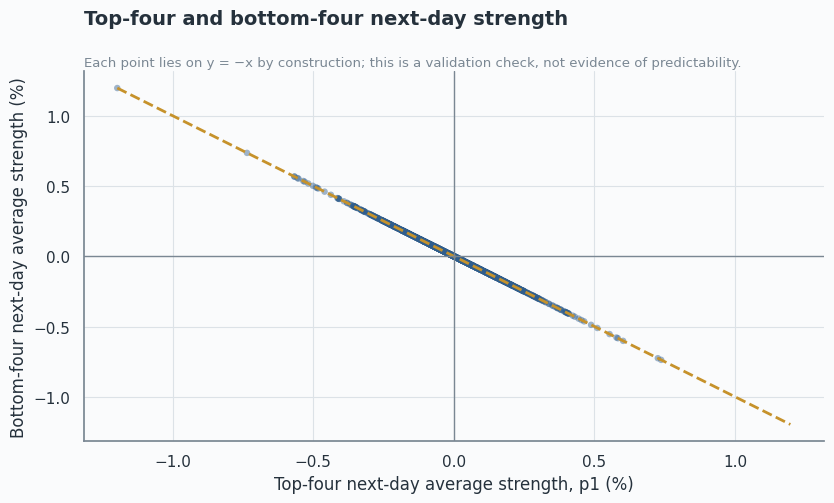

In [8]:
# Structural check: top and bottom groups are exact mirrors
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.scatter(
    results["p1_top4_avg"],
    results["p1_bottom4_avg"],
    s=22, alpha=0.45, color=BLUE, edgecolor="none"
)
limit = np.abs(results[["p1_top4_avg", "p1_bottom4_avg"]].to_numpy()).max()
ax.plot([-limit, limit], [limit, -limit], color=GOLD, lw=2, ls="--")
ax.axhline(0, color=GREY, lw=1)
ax.axvline(0, color=GREY, lw=1)
ax.set(
    xlabel="Top-four next-day average strength, p1 (%)",
    ylabel="Bottom-four next-day average strength (%)",
)
ax.set_title(
    "Top-four and bottom-four next-day strength",
    loc="left", pad=34, fontsize=14, fontweight="bold"
)
ax.text(
    0.00, 1.015,
    "Each point lies on y = −x by construction; this is a validation check, not evidence of predictability.",
    transform=ax.transAxes, color=GREY, fontsize=9.5
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

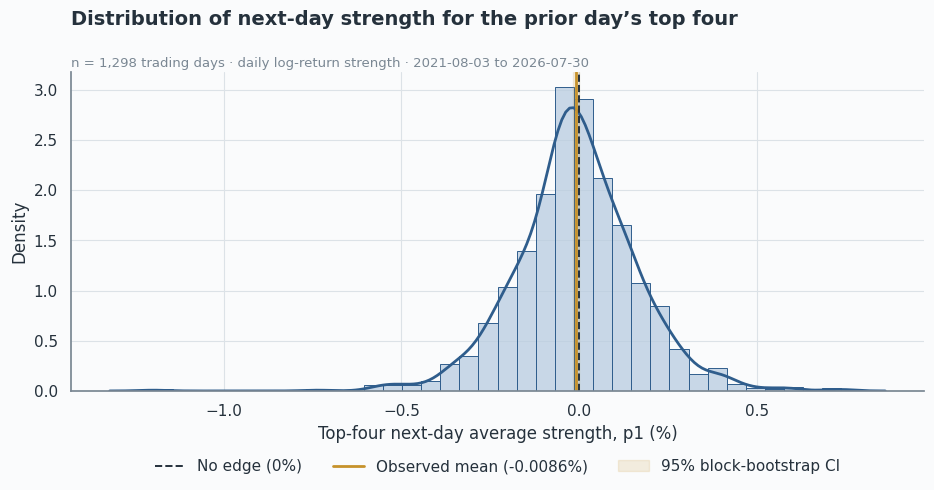

In [9]:
# Primary outcome: the next-day distribution is centered close to zero
fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.histplot(
    results["p1_top4_avg"], bins=36, stat="density",
    color=BLUE_LIGHT, edgecolor=BLUE, linewidth=0.7, ax=ax
)
sns.kdeplot(results["p1_top4_avg"], color=BLUE, lw=2, ax=ax)
ax.axvline(0, color=INK, lw=1.4, ls="--", label="No edge (0%)")
ax.axvline(results["p1_top4_avg"].mean(), color=GOLD, lw=2,
           label=f"Observed mean ({results['p1_top4_avg'].mean():+.4f}%)")
ax.axvspan(ci_low, ci_high, color=GOLD, alpha=0.14, label="95% block-bootstrap CI")
ax.set(
    xlabel="Top-four next-day average strength, p1 (%)",
    ylabel="Density",
)
ax.set_title(
    "Distribution of next-day strength for the prior day’s top four",
    loc="left", pad=34, fontsize=14, fontweight="bold"
)
ax.text(
    0.00, 1.015,
    f"n = {len(results):,} trading days · daily log-return strength · {results.index.min().date()} to {results.index.max().date()}",
    transform=ax.transAxes, color=GREY, fontsize=9.5
)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.17))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The estimated next-day mean is **-0.0086%**, and the 95% block-bootstrap interval spans zero. That mean test alone does not establish an unconditional edge. However, positive outcomes occur on only **46.6%** of days, and the two-sided sign test ($p=0.016$) points to a small directional tilt toward reversal. The mean and sign results differ because the mean is more sensitive to a few large positive days.

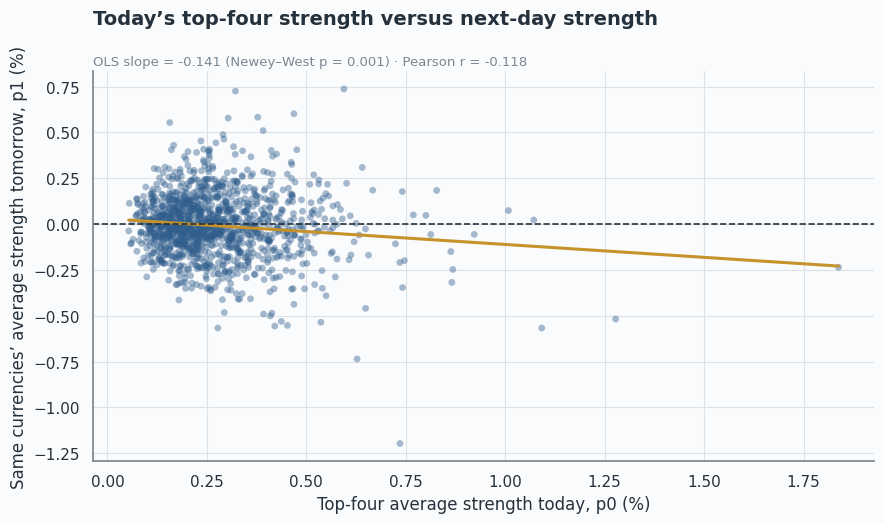

,estimate
p0→p1 slope,-0.1407
Newey–West slope SE,0.0437
Slope p-value,0.0013
Pearson correlation,-0.1183
Correlation p-value,0.0000


In [10]:
def newey_west_regression(x, y, max_lag=5):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.solve(design.T @ design, design.T @ y)
    residuals = y - design @ beta
    meat = np.zeros((2, 2))

    for position in range(len(y)):
        vector = design[position][:, None]
        meat += residuals[position] ** 2 * (vector @ vector.T)

    for lag in range(1, max_lag + 1):
        weight = 1 - lag / (max_lag + 1)
        cross = np.zeros((2, 2))
        for position in range(lag, len(y)):
            current = design[position][:, None]
            previous = design[position - lag][:, None]
            cross += (
                residuals[position] * residuals[position - lag]
                * (current @ previous.T)
            )
        meat += weight * (cross + cross.T)

    bread = np.linalg.inv(design.T @ design)
    covariance = bread @ meat @ bread
    slope_se = np.sqrt(covariance[1, 1])
    slope_t = beta[1] / slope_se
    slope_p = 2 * stats.t.sf(abs(slope_t), df=len(y) - 2)
    return {
        "intercept": beta[0], "slope": beta[1],
        "slope_se": slope_se, "slope_p": slope_p,
    }


x = results["p0_top4_avg"].to_numpy()
y = results["p1_top4_avg"].to_numpy()
regression = newey_west_regression(x, y, max_lag=5)
correlation, correlation_p = stats.pearsonr(x, y)

fig, ax = plt.subplots(figsize=(9.0, 5.4))
ax.scatter(x, y, s=24, alpha=0.42, color=BLUE, edgecolor="none")
x_line = np.linspace(x.min(), x.max(), 200)
y_line = regression["intercept"] + regression["slope"] * x_line
ax.plot(x_line, y_line, color=GOLD, lw=2.2)
ax.axhline(0, color=INK, lw=1.2, ls="--")
ax.set(
    xlabel="Top-four average strength today, p0 (%)",
    ylabel="Same currencies’ average strength tomorrow, p1 (%)",
)
ax.set_title(
    "Today’s top-four strength versus next-day strength",
    loc="left", pad=34, fontsize=14, fontweight="bold"
)
ax.text(
    0.00, 1.015,
    f"OLS slope = {regression['slope']:+.3f} (Newey–West p = {regression['slope_p']:.3f}) · Pearson r = {correlation:+.3f}",
    transform=ax.transAxes, color=GREY, fontsize=9.5
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

regression_table = pd.DataFrame({
    "estimate": [regression["slope"], regression["slope_se"], regression["slope_p"], correlation, correlation_p],
}, index=["p0→p1 slope", "Newey–West slope SE", "Slope p-value", "Pearson correlation", "Correlation p-value"])
display(regression_table)

The fitted slope is **-0.141** with $p=0.001$, and the correlation is **-0.118** with $p=0.000$. The negative relationship is modest but statistically detectable: larger day-0 leader strength is associated with weaker day-1 performance. This is conditional mean reversion, even though the unconditional average remains close to zero.

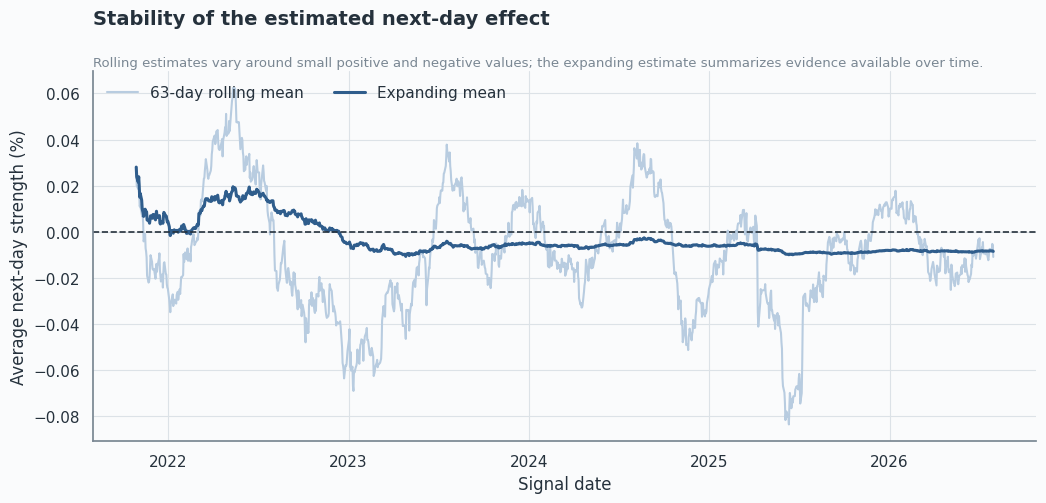

In [11]:
# Stability check: a 63-trading-day rolling estimate and the expanding mean
stability = pd.DataFrame(index=results.index)
stability["63-day rolling mean"] = results["p1_top4_avg"].rolling(63).mean()
stability["Expanding mean"] = results["p1_top4_avg"].expanding(63).mean()

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(stability.index, stability["63-day rolling mean"], color=BLUE_LIGHT, lw=1.5,
        label="63-day rolling mean")
ax.plot(stability.index, stability["Expanding mean"], color=BLUE, lw=2.2,
        label="Expanding mean")
ax.axhline(0, color=INK, lw=1.2, ls="--")
ax.set(
    xlabel="Signal date",
    ylabel="Average next-day strength (%)",
)
ax.set_title(
    "Stability of the estimated next-day effect",
    loc="left", pad=34, fontsize=14, fontweight="bold"
)
ax.text(
    0.00, 1.015,
    "Rolling estimates vary around small positive and negative values; the expanding estimate summarizes evidence available over time.",
    transform=ax.transAxes, color=GREY, fontsize=9.5
)
ax.legend(frameon=False, ncol=2, loc="upper left")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

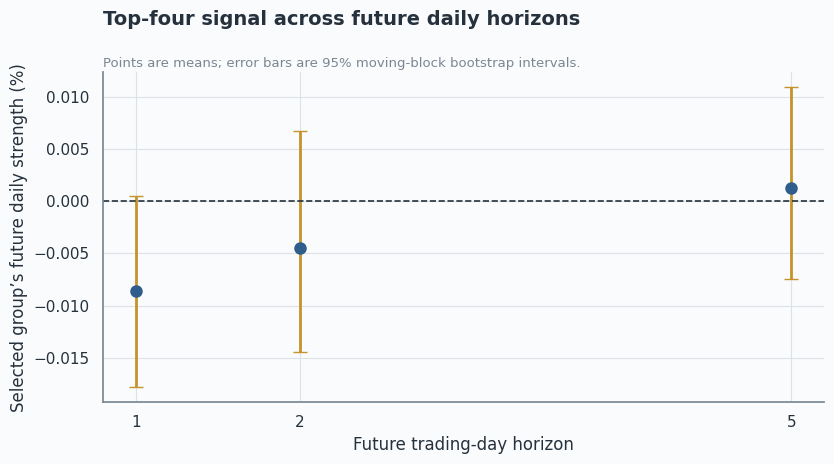

,mean,ci_low,ci_high,positive_share,observations
horizon,,,,,
1,-0.0086,-0.0178,0.0005,0.4661,1298
2,-0.0045,-0.0144,0.0067,0.4634,1297
5,0.0013,-0.0075,0.0109,0.4915,1294


In [12]:
# Robustness: inspect future daily strength at 1, 2, and 5 trading-day horizons
horizon_rows = []
for horizon in [1, 2, 5]:
    values = []
    for position in range(len(groups) - horizon):
        selected = groups.iloc[position]["top_4"]
        values.append(currency_strength.iloc[position + horizon][selected].mean())
    values = np.asarray(values)
    low, high = block_bootstrap_mean_ci(values, seed=RANDOM_SEED + horizon)
    horizon_rows.append({
        "horizon": horizon,
        "mean": values.mean(),
        "ci_low": low,
        "ci_high": high,
        "positive_share": (values > 0).mean(),
        "observations": len(values),
    })

horizon_results = pd.DataFrame(horizon_rows)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
errors = np.vstack([
    horizon_results["mean"] - horizon_results["ci_low"],
    horizon_results["ci_high"] - horizon_results["mean"],
])
ax.errorbar(
    horizon_results["horizon"], horizon_results["mean"], yerr=errors,
    fmt="o", markersize=8, color=BLUE, ecolor=GOLD,
    elinewidth=2, capsize=5
)
ax.axhline(0, color=INK, lw=1.2, ls="--")
ax.set(
    xticks=horizon_results["horizon"],
    xlabel="Future trading-day horizon",
    ylabel="Selected group’s future daily strength (%)",
)
ax.set_title(
    "Top-four signal across future daily horizons",
    loc="left", pad=34, fontsize=14, fontweight="bold"
)
ax.text(
    0.00, 1.015,
    "Points are means; error bars are 95% moving-block bootstrap intervals.",
    transform=ax.transAxes, color=GREY, fontsize=9.5
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
display(horizon_results.set_index("horizon"))

In [13]:
# Data-source sensitivity: reconstruct strength from only the seven USD legs
usd_spoke_strength = pd.DataFrame(
    0.0, index=pair_returns.index, columns=CURRENCIES
)
for currency in CURRENCIES:
    if currency != "USD":
        usd_spoke_strength[currency] = directed_return(currency, "USD")
usd_spoke_strength = usd_spoke_strength.sub(
    usd_spoke_strength.mean(axis=1), axis=0
)

usd_top4 = usd_spoke_strength.apply(
    lambda row: list(row.nlargest(4).index), axis=1
)
usd_records = []
for position in range(len(usd_top4) - 1):
    selected = usd_top4.iloc[position]
    usd_records.append({
        "p0": usd_spoke_strength.iloc[position][selected].mean(),
        "p1": usd_spoke_strength.iloc[position + 1][selected].mean(),
    })
usd_results = pd.DataFrame(usd_records)
usd_regression = newey_west_regression(usd_results["p0"], usd_results["p1"])
usd_ci = block_bootstrap_mean_ci(usd_results["p1"], seed=RANDOM_SEED + 100)

usd_sensitivity = pd.Series({
    "next_day_mean_pct": usd_results["p1"].mean(),
    "continuation_rate": (usd_results["p1"] > 0).mean(),
    "bootstrap_ci_low_pct": usd_ci[0],
    "bootstrap_ci_high_pct": usd_ci[1],
    "p0_to_p1_slope": usd_regression["slope"],
    "newey_west_slope_p_value": usd_regression["slope_p"],
}).to_frame("value")
display(usd_sensitivity)

,value
next_day_mean_pct,-0.0066
continuation_rate,0.4807
bootstrap_ci_low_pct,-0.0149
bootstrap_ci_high_pct,0.0016
p0_to_p1_slope,-0.1460
newey_west_slope_p_value,0.0015


## Takeaways

### What the evidence supports

1. **The top/bottom symmetry is structural.** Equal-and-opposite group averages validate the zero-sum construction; they do not show that returns are random.
2. **There is no evidence of momentum.** The top-four group’s mean next-day score was -0.0086%, with a 95% block-bootstrap interval of [-0.0179%, +0.0003%].
3. **There is evidence of weak one-day mean reversion.** Continuation occurred on 46.6% of days (sign-test $p=0.016$), and today’s top-four magnitude had a slope of -0.141 against tomorrow’s outcome ($p=0.001$).
4. **The dependence survives a cleaner data construction.** Using only seven USD legs yields a slope of -0.146 ($p=0.002$), so redundant cross-rate noise does not explain the result by itself.
5. **The pattern fades beyond day 1.** The descriptive two- and five-day-ahead daily-strength intervals span zero, so the reversal does not look persistent.
6. **The conclusion is appropriately narrow.** The evidence contradicts the original “complete randomness” claim, but it does not establish a profitable strategy or a universal FX law.

### Decision

**Reject the top-four ranking as a standalone momentum signal.** Keep the observed reversal as a research hypothesis only. Before deployment, require a frozen out-of-sample period, an investable portfolio mapping, and net-of-cost performance.

### Limitations

- Yahoo Finance closes may not share an institutional FX fixing time across every cross.
- The equal-weighted strength score reuses currencies across pairs and is not directly tradable.
- No spreads, slippage, financing, or execution constraints are modeled.
- Statistical non-significance is not proof of market efficiency or independence.
- Exploring additional horizons after seeing the one-day result is descriptive and should not be treated as confirmatory evidence.

### Next steps

- Freeze a later out-of-sample period before changing the feature definition.
- Compare close-to-close, intraday, and institutional fixing-time data.
- Test whether volatility, carry, macro regimes, or dispersion condition the signal.
- Translate the index into an investable long/short construction and evaluate returns after costs.

---

**Reproducibility:** run all cells from top to bottom. The frozen input is `data/fx_prices_2021-08-01_2026-08-01.csv`; deleting it triggers a fresh download for the configured date range.